In [1]:
from utils import * 
import numpy as np
import shutil 
from matplotlib.lines import Line2D
from datetime import datetime
import itertools
import os
import re
import orjson
import ast  
import shutil 
import networkx as nx 
from ppi import get_contacts, get_contact_graph, plot_contact_graph

%load_ext autoreload 
%autoreload 2



In [2]:
level_1_conserved_cluster_ids = [8, 7, 0, 4, 5, 6, 1, 3, 2]
level_2_conserved_cluster_ids = [9, 12, 10, 13, 11]
level_3_conserved_cluster_ids = [18, 42, 33, 25, 17, 19, 20, 21, 50, 31, 40, 27, 34, 15, 14, 54, 24, 23, 41, 39, 57, 47, 48, 51, 45, 35, 49, 28, 62, 29]

In [3]:
# Interested in looking at potential protein-protein interactions, particularly potential interactions with the ATPase as a possible hint at function. 

genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()
genes_df['alphafold_id'] = genes_df.apply(lambda row : f'{row.genome_id}_cluster_{int(row.cluster_id)}_1mer', axis=1)
genes_df = genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].copy()

FASTAFile.from_df(genes_df).write('../data/genes/level_1_conserved_clusters.faa')

In [4]:
def get_msas_unpaired(gene_ids:list, dir_path:str='../data/genes/mmseqs/'):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}
 

In [5]:
names = list() # Store the names of the AlphaFold jobs to access the output directories.
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/ppi-level_1_conserved' # Directory name to match what is required on biotite.
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output' # Directory name to match what is required on biotite

ALPHAFOLD_PARAMS = dict()
ALPHAFOLD_PARAMS['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
ALPHAFOLD_PARAMS['--num_recycles'] = 10 # Number of recycles to use during inference (refinement steps). 10 by default. 
os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)


for genome_id, df in genes_df.groupby('genome_id'):

    pairs = list(itertools.combinations(df.reset_index(names='gene_id').to_dict(orient='records'), 2))
    pairs += [(entry, entry) for entry in df.reset_index(names='gene_id').to_dict(orient='records')] # Also add homo-dimers, which are not included in combinations. 
    for pair in pairs:

        alphafold_ids = [ pair[0]['alphafold_id'],  pair[1]['alphafold_id']]
        gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
        seqs = [pair[0]['seq'], pair[1]['seq']]

        name = '-'.join(alphafold_ids)
        names.append(name)
        
        msas = get_msas_unpaired(gene_ids)
        file = AlphaFoldInputFile(name, dialect='alphafold3', num_seeds=10, version=2)

        for gene_id, alphafold_id, seq in zip(gene_ids, alphafold_ids, seqs):
            file.add_seq(seq, paired_msa="", unpaired_msa=msas[gene_id], description=alphafold_id)

        file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{name}.json'))

print('Number of co-folds:', len(names), end='\n\n')

cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(ALPHAFOLD_INPUT_DIR)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd += [f'{param} {value}' for param, value in ALPHAFOLD_PARAMS.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

Number of co-folds: 442

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/ppi-level_1_conserved/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 1 --num_recycles 10"


Loading contact data.:   0%|          | 1/442 [00:01<09:24,  1.28s/it]

get_contacts: No contacts found for bz_0_cluster_8_1mer-bz_0_cluster_7_1mer


Loading contact data.:   1%|          | 3/442 [00:05<11:00,  1.50s/it]

get_contacts: No contacts found for bz_0_cluster_8_1mer-bz_0_cluster_0_1mer
get_contacts: No contacts found for bz_0_cluster_8_1mer-bz_0_cluster_4_1mer


Loading contact data.:   1%|          | 4/442 [00:05<07:17,  1.00it/s]

...

Loading contact data.:  98%|█████████▊| 435/442 [09:35<00:06,  1.11it/s]

get_contacts: No contacts found for bz_9_cluster_3_1mer-bz_9_cluster_3_1mer


Loading contact data.:  99%|█████████▉| 439/442 [09:36<00:01,  2.53it/s]

get_contacts: No contacts found for bz_9_cluster_4_1mer-bz_9_cluster_4_1mer


Loading contact data.: 100%|██████████| 442/442 [09:44<00:00,  1.32s/it]


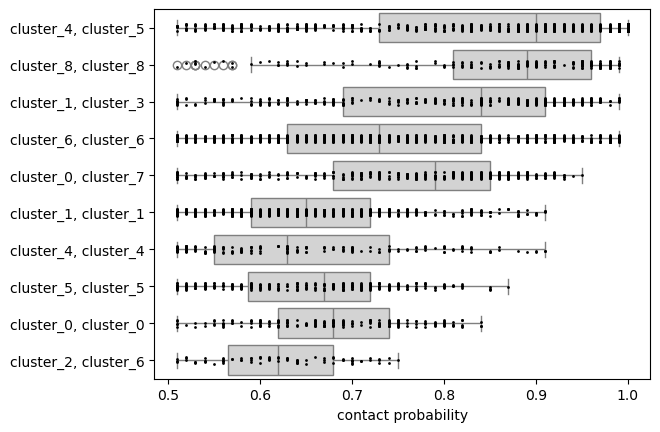

Number of genomes with cluster_0, cluster_0 in contact: 8
Number of genomes with cluster_0, cluster_7 in contact: 10
Number of genomes with cluster_1, cluster_1 in contact: 8
Number of genomes with cluster_1, cluster_3 in contact: 11
Number of genomes with cluster_2, cluster_6 in contact: 6
Number of genomes with cluster_4, cluster_4 in contact: 8
Number of genomes with cluster_4, cluster_5 in contact: 10
Number of genomes with cluster_5, cluster_5 in contact: 7
Number of genomes with cluster_6, cluster_6 in contact: 10
Number of genomes with cluster_8, cluster_8 in contact: 8


In [6]:
if not os.path.exists('analysis-1-ppi-level_1_conserved_contacts.csv'):
    contacts_df = list()
    for name in tqdm(names, desc='Loading contact data.'):
        output = AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, name))
        contacts_df.append(get_contacts(output, min_contact_prob=0.3))
    contacts_df = pd.concat(contacts_df)
    contacts_df.to_csv('analysis-1-ppi-level_1_conserved_contacts.csv', index=False)
else:
    contacts_df = pd.read_csv('analysis-1-ppi-level_1_conserved_contacts.csv')


def get_contact_id(row):
    '''Construct a contact_id from a contact_df entry. These IDs are of the form {node_type}:{position}.'''
    contact_id = sorted([f'{row.chain_id_0}:{row.residue_num_0}', f'{row.chain_id_1}:{row.residue_num_1}'])
    return '-'.join(contact_id)

contacts_df['cluster_ids'] = [', '.join(sorted(re.findall(r'cluster_\d+', name))) for name in contacts_df['name']]
contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)
contacts_df['genome_id'] = contacts_df.name.apply(get_genome_id)

figure_df = contacts_df.copy()
figure_df = figure_df[figure_df.contact_prob > 0.5].copy()
figure_df['num_genomes'] = figure_df.cluster_ids.map(contacts_df.groupby('cluster_ids').apply(lambda df : df.dropna().genome_id.nunique()))
figure_df = figure_df[figure_df.num_genomes >= 8].copy()
figure_df = figure_df.sort_values('contact_prob', ascending=False).drop_duplicates(['name', 'contact_id'])


fig, ax = plt.subplots()
sns.boxplot(figure_df, y='cluster_ids', x='contact_prob', color='lightgray')
# sns.stripplot(figure_df, y='cluster_ids', x='contact_prob', hue='pae', palette='Grays')
sns.stripplot(figure_df, y='cluster_ids', x='contact_prob', color='black', s=2)
ax.set_ylabel('')
ax.set_xlabel('contact probability')
plt.show()

for cluster_ids, df in figure_df.groupby('cluster_ids'):
    print(f'Number of genomes with {cluster_ids} in contact:', df.genome_id.nunique())

In [7]:
# output = AlphaFoldOutput('../data/genes/alphafold/af_output/bz_0_cluster_3_1mer-bz_0_cluster_2_1mer')
# output = AlphaFoldOutput('../data/genes/alphafold/af_output/bz_9_cluster_2_1mer-bz_9_cluster_3_1mer')

# print('ipTM:', output.get_iptms(best_model=True))
# print('pTM:', output.get_ptms(best_model=True))
# contact_probs = output.get_contact_probs(best_model=True)

# figure_df = pd.DataFrame(contact_probs, index=output.get_token_chain_ids(), columns=output.get_token_chain_ids())

# row_idxs = np.where(figure_df.index == 'A')[0]
# col_idxs = np.where(figure_df.columns == 'B')[0]
# figure_df = figure_df.iloc[row_idxs, col_idxs]
# sns.heatmap(figure_df)


In [ ]:
contacts_df[contacts_df.cluster_ids == 'cluster_2, cluster_3']#.genome_id.unique()

contacts_df

,idx_0,chain_id_0,residue_num_0,residue_0,seq_0,idx_1,chain_id_1,residue_num_1,residue_1,seq_1,pae,contact_prob,name,model,cluster_ids,contact_id,genome_id
0,13,A,13,I,MYHLLDNKKFLDEIFKIDINELRIALYKKYERKDIAEKLNISDVQV...,131,B,62,L,MWNPFKTLTKNAPTIKDISRIPSDIKDSAYNIKANKITIRYFMDLN...,29.4,0.32,bz_0_cluster_8_1mer-bz_0_cluster_6_1mer,seed-8_sample-0,"cluster_6, cluster_8",A:13-B:62,bz_0
1,18,A,18,I,MYHLLDNKKFLDEIFKIDINELRIALYKKYERKDIAEKLNISDVQV...,128,B,59,N,MWNPFKTLTKNAPTIKDISRIPSDIKDSAYNIKANKITIRYFMDLN...,30.2,0.33,bz_0_cluster_8_1mer-bz_0_cluster_6_1mer,seed-8_sample-0,"cluster_6, cluster_8",A:18-B:59,bz_0
2,18,A,18,I,MYHLLDNKKFLDEIFKIDINELRIALYKKYERKDIAEKLNISDVQV...,130,B,61,G,MWNPFKTLTKNAPTIKDISRIPSDIKDSAYNIKANKITIRYFMDLN...,30.1,0.38,bz_0_cluster_8_1mer-bz_0_cluster_6_1mer,seed-8_sample-0,"cluster_6, cluster_8",A:18-B:61,bz_0
3,54,A,54,P,MYHLLDNKKFLDEIFKIDINELRIALYKKYERKDIAEKLNISDVQV...,127,B,58,H,MWNPFKTLTKNAPTIKDISRIPSDIKDSAYNIKANKITIRYFMDLN...,30.1,0.32,bz_0_cluster_8_1mer-bz_0_cluster_6_1mer,seed-8_sample-0,"cluster_6, cluster_8",A:54-B:58,bz_0
4,54,A,54,P,MYHLLDNKKFLDEIFKIDINELRIALYKKYERKDIAEKLNISDVQV...,132,B,63,P,MWNPFKTLTKNAPTIKDISRIPSDIKDSAYNIKANKITIRYFMDLN...,29.1,0.35,bz_0_cluster_8_1mer-bz_0_cluster_6_1mer,seed-8_sample-0,"cluster_6, cluster_8",A:54-B:63,bz_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57118,54,A,54,L,MINLNEIFNTDINKLRDKIYLKYSRKEIADKLDLSEIQISRLLNGK...,65,B,3,L,MINLNEIFNTDINKLRDKIYLKYSRKEIADKLDLSEIQISRLLNGK...,2.7,0.90,bz_9_cluster_8_1mer-bz_9_cluster_8_1mer,seed-7_sample-0,"cluster_8, cluster_8",A:54-B:3,bz_9
57119,54,A,54,L,MINLNEIFNTDINKLRDKIYLKYSRKEIADKLDLSEIQISRLLNGK...,68,B,6,I,MINLNEIFNTDINKLRDKIYLKYSRKEIADKLDLSEIQISRLLNGK...,2.4,0.88,bz_9_cluster_8_1mer-bz_9_cluster_8_1mer,seed-7_sample-0,"cluster_8, cluster_8",A:54-B:6,bz_9
57120,54,A,54,L,MINLNEIFNTDINKLRDKIYLKYSRKEIADKLDLSEIQISRLLNGK...,69,B,7,F,MINLNEIFNTDINKLRDKIYLKYSRKEIADKLDLSEIQISRLLNGK...,2.6,0.90,bz_9_cluster_8_1mer-bz_9_cluster_8_1mer,seed-7_sample-0,"cluster_8, cluster_8",A:54-B:7,bz_9
57121,55,A,55,I,MINLNEIFNTDINKLRDKIYLKYSRKEIADKLDLSEIQISRLLNGK...,65,B,3,L,MINLNEIFNTDINKLRDKIYLKYSRKEIADKLDLSEIQISRLLNGK...,3.4,0.86,bz_9_cluster_8_1mer-bz_9_cluster_8_1mer,seed-7_sample-0,"cluster_8, cluster_8",A:55-B:3,bz_9


In [17]:
# Even without strong MSAs, it could be informative to look at protein-protein interaction predictions for all supported contacts. 
# It is also possible that proteins with weak folds have stronger structural predictions when co-folded. 

# In order to limit the search space, I will co-fold only ORFs with some support:
#   (1) Predicted by Prodigal, which indicated there is some signal that the region is protein-coding. 
#   (2) Conserved, i.e. detected in at least two genomes. 
#   (3) Has some InterProScan annotation. 
#   (4) Has a valid ColabFold structure (at least 50 consecutive residues with pLDDT > 70)

supported_gene_ids = np.loadtxt('analysis-1-cluster-supported_gene_ids.txt', dtype=str)

genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df = genes_df.loc[supported_gene_ids].copy()
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))

# In order to reduce the runtime (which is astronomical if AlphaFold tries to generate MSAs for each complex), I will re-use
# the ColabFold-generated MSAs, which are already in the required a3m format. 

msas = dict()
for genome_id, df in genes_df.groupby('genome_id'):
    dir_path = os.path.join('../data/genes/colabfold/', genome_id)
    msas.update(get_msas_unpaired(df.index.tolist(), dir_path=dir_path))
# # Remove the comment lines at the beginning of each MSA. 
# msas = {gene_id:'\n'.join(msa.split('\n')[1:]) for gene_id, msa in msas.items()}

counts = np.array([msa.count('>') for msa in msas.values()])
print('Number of MSAs for supported genes with > 5 sequences:', (counts > 6).sum())
print('Number of supported genes:', len(supported_gene_ids))


Number of MSAs for supported genes with > 5 sequences: 107
Number of supported genes: 536


In [18]:
genome_id = 'bz_0'

ALPHAFOLD_INPUT_DIR = f'../data/genes/alphafold/af_input/ppi-{genome_id}'
ALPHAFOLD_OUTPUT_DIR = f'../data/genes/alphafold/af_output/ppi-{genome_id}' 

ALPHAFOLD_PARAMS = dict()
ALPHAFOLD_PARAMS['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
ALPHAFOLD_PARAMS['--num_recycles'] = 5 # Number of recycles to use during inference (refinement steps). 10 by default, dropped here to mitigate runtime. 
os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)

names = list()

df = genes_df[genes_df.genome_id == genome_id].copy()

pairs = list(itertools.combinations(df.reset_index(names='gene_id').to_dict(orient='records'), 2))
pairs += [(entry, entry) for entry in df.reset_index(names='gene_id').to_dict(orient='records')] # Also add homo-dimers, which are not included in combinations. 
for pair in pairs:

    gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
    seqs = [pair[0]['seq'], pair[1]['seq']]

    name = '-'.join(gene_ids)
    names.append(name)

    file = AlphaFoldInputFile(name, dialect='alphafold3', num_seeds=3, version=2)

    for gene_id, seq in zip(gene_ids, seqs):
        file.add_seq(seq, paired_msa='', unpaired_msa=msas[gene_id])

    file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{name}.json'))


print('Number of co-folds:', len(names), end='\n\n')

cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(ALPHAFOLD_INPUT_DIR)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd += [f'{param} {value}' for param, value in ALPHAFOLD_PARAMS.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

Number of co-folds: 1431

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/ppi-bz_0/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 1 --num_recycles 5"


In [19]:
if not os.path.exists(f'analysis-1-ppi-{genome_id}_contacts.csv'):
    contacts_df = list()
    for name in tqdm(names, desc='Loading contact data.'):
        output = AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, name))
        contacts_df.append(get_contacts(output, min_contact_prob=0.3))
    contacts_df = pd.concat(contacts_df)
    contacts_df.to_csv(f'analysis-1-ppi-{genome_id}_contacts.csv', index=False)
else:
    contacts_df = pd.read_csv(f'analysis-1-ppi-{genome_id}_contacts.csv')

print(f'Number of potential contacts in the {genome_id} genome:', contacts_df.name.nunique())
for path in glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*')):
    name = os.path.basename(path)
    if name not in contacts_df.name.unique():
        shutil.rmtree(path)

Number of potential contacts in the bz_0 genome: 139


In [95]:
# Do any of the co-folded proteins have a higher ptm than either individually-folded protein?
for path in glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*')):
    output = AlphaFoldOutput(path)
    gene_ids = output.name.split('-')
    cluster_ids = genes_df.loc[gene_ids].cluster_id.values.astype(int).astype(str).tolist()
    contact_prob = contacts_df[contacts_df.name == output.name].sort_values('contact_prob', ascending=False).contact_prob.iloc[0]

    ptms = [ColabFoldOutput(f'../data/genes/colabfold/{genome_id}/{gene_id}').get_ptms(best_model=True) for gene_id in gene_ids]
    delta = output.get_ptms(best_model=True) - max(ptms)
    if delta > 0.1:
        print(f"pTM increase for clusters {', '.join(cluster_ids)}:", np.round(delta, 2), 'contact probability', np.round(contact_prob, 2))

    # break

pTM increase for clusters 19, 19: 0.25 contact probability 0.81
pTM increase for clusters 1439, 2: 0.23 contact probability 0.59
pTM increase for clusters 8, 2: 0.23 contact probability 0.92
pTM increase for clusters 1432, 19: 0.1 contact probability 0.79
pTM increase for clusters 33, 1370: 0.24 contact probability 0.83
pTM increase for clusters 1425, 1421: 0.14 contact probability 0.7
pTM increase for clusters 1448, 8: 0.21 contact probability 0.86
pTM increase for clusters 1421, 1421: 0.2 contact probability 0.84
pTM increase for clusters 33, 33: 0.5 contact probability 0.98
pTM increase for clusters 17, 17: 0.19 contact probability 0.84
pTM increase for clusters 8, 8: 0.31 contact probability 0.97
pTM increase for clusters 1413, 2: 0.13 contact probability 0.64
pTM increase for clusters 1430, 2: 0.18 contact probability 0.88
pTM increase for clusters 1370, 1370: 0.34 contact probability 0.96
pTM increase for clusters 1447, 2: 0.13 contact probability 0.52
pTM increase for clusters 1

In [21]:
# Using the same get_contact_id form as for the residue-residue contacts. Because the get_contact_graph function drops duplicate contact_ids, ensuring that (1) the
# node_type is set by the gene_id, not the chain_id, and (2) fixing position as 0, there will be one unique contact per protein pair.

def get_contact_id(row):
    '''Construct a contact_id from a contact_df entry. These IDs are of the form {node_type}:{position}. The contact IDs are necessarily order-invariant; 
    in other words, the contact ID for an edge (u, v) must be the same ad the contact ID for (v, u).'''
    contact_id = sorted([f'{int(row.cluster_id_0)}:0', f'{int(row.cluster_id_1)}:0'])
    return '-'.join(contact_id)

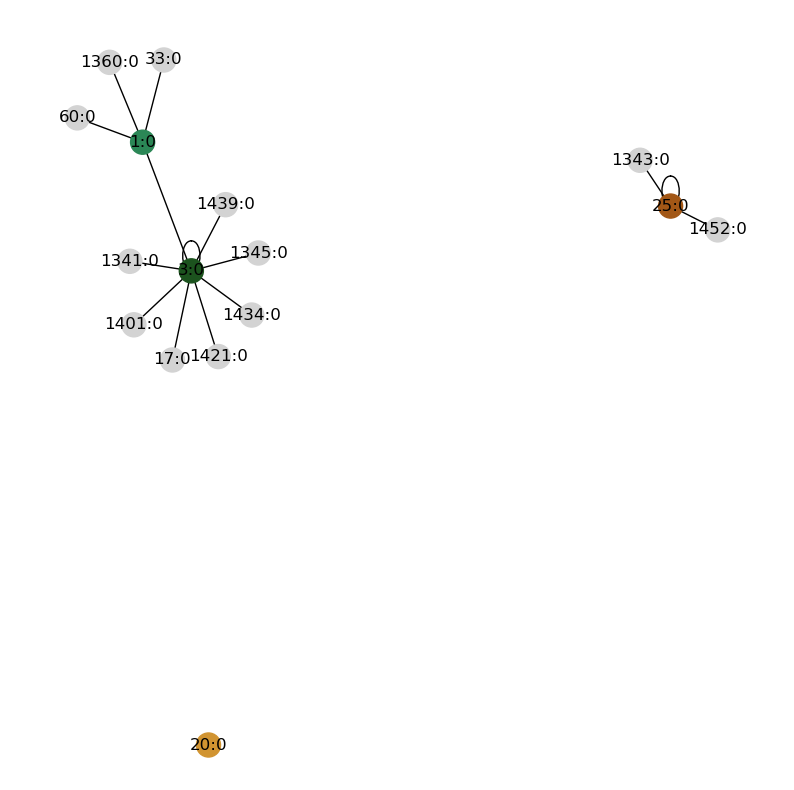

In [22]:
cluster_1_gene_id = genes_df[(genes_df.cluster_id == 1) & (genes_df.genome_id == genome_id)].index[0]
cluster_3_gene_id = genes_df[(genes_df.cluster_id == 3) & (genes_df.genome_id == genome_id)].index[0]
cluster_25_gene_id = genes_df[(genes_df.cluster_id == 3) & (genes_df.genome_id == genome_id)].index[0]

contacts_df[contacts_df.name.str.contains(cluster_1_gene_id)].name.nunique()
contacts_df[contacts_df.name.str.contains(cluster_1_gene_id)]

seq_to_gene_id_map = genes_df.reset_index(names='gene_id').set_index('seq').gene_id.to_dict()
gene_id_to_cluster_id_map = genes_df.cluster_id.to_dict()

contacts_df['gene_id_0'] = contacts_df.seq_0.map(seq_to_gene_id_map)
contacts_df['gene_id_1'] = contacts_df.seq_1.map(seq_to_gene_id_map)
contacts_df['cluster_id_0'] = contacts_df.gene_id_0.map(gene_id_to_cluster_id_map)
contacts_df['cluster_id_1'] = contacts_df.gene_id_1.map(gene_id_to_cluster_id_map)
contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)


palette = dict()
palette = {f'{cluster_id}':'lightgray' for cluster_id in genes_df.cluster_id.astype(int).unique()}
# palette.update({cluster_id:'gray' for cluster_id in level_2_conserved_cluster_ids})
# palette.update({cluster_id:'black' for cluster_id in level_1_conserved_cluster_ids})
# palette.update({cluster_id:'gray' for cluster_id in level_3_conserved_cluster_ids})
palette.update({'1':"#2B8756", '3':"#1C531E", '2':"#86C589", '6':"#91C449", '20':"#D19431", '25':"#A25716"})

graph = get_contact_graph(contacts_df, min_num_models=3, min_contact_prob=0, node_ids=['1:0', '20:0', '25:0', '3:0'])
plot_contact_graph(graph, pos=nx.spring_layout(graph, k=0.3), palette=palette)



In [75]:
contacts_df[contacts_df.contact_id.str.contains('25')]

,idx_0,chain_id_0,residue_num_0,residue_0,seq_0,idx_1,chain_id_1,residue_num_1,residue_1,seq_1,pae,contact_prob,name,model,gene_id_0,gene_id_1,cluster_id_0,cluster_id_1,contact_id
679,32,A,32,K,MTTHYYIKTKFWLNNIFCNNSIHIADKTKNIKKVTCVPCLLKLRNM...,72,B,21,E,MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPD...,14.5,0.51,orfm.bz_0.1_16-orfm.bz_0.1_70,seed-2_sample-0,orfm.bz_0.1_16,orfm.bz_0.1_70,1452,25,1452:0-25:0
680,33,A,33,V,MTTHYYIKTKFWLNNIFCNNSIHIADKTKNIKKVTCVPCLLKLRNM...,73,B,22,I,MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPD...,15.1,0.54,orfm.bz_0.1_16-orfm.bz_0.1_70,seed-2_sample-0,orfm.bz_0.1_16,orfm.bz_0.1_70,1452,25,1452:0-25:0
681,38,A,38,C,MTTHYYIKTKFWLNNIFCNNSIHIADKTKNIKKVTCVPCLLKLRNM...,169,B,118,L,MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPD...,11.5,0.52,orfm.bz_0.1_16-orfm.bz_0.1_70,seed-2_sample-0,orfm.bz_0.1_16,orfm.bz_0.1_70,1452,25,1452:0-25:0
682,39,A,39,L,MTTHYYIKTKFWLNNIFCNNSIHIADKTKNIKKVTCVPCLLKLRNM...,71,B,20,F,MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPD...,12.8,0.58,orfm.bz_0.1_16-orfm.bz_0.1_70,seed-2_sample-0,orfm.bz_0.1_16,orfm.bz_0.1_70,1452,25,1452:0-25:0
683,41,A,41,K,MTTHYYIKTKFWLNNIFCNNSIHIADKTKNIKKVTCVPCLLKLRNM...,169,B,118,L,MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPD...,11.8,0.55,orfm.bz_0.1_16-orfm.bz_0.1_70,seed-2_sample-0,orfm.bz_0.1_16,orfm.bz_0.1_70,1452,25,1452:0-25:0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6024,98,A,98,S,MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPD...,149,B,10,F,MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPD...,12.8,0.56,orfm.bz_0.1_70-orfm.bz_0.1_70,seed-1_sample-0,orfm.bz_0.1_70,orfm.bz_0.1_70,25,25,25:0-25:0
6025,98,A,98,S,MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPD...,150,B,11,K,MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPD...,15.9,0.57,orfm.bz_0.1_70-orfm.bz_0.1_70,seed-1_sample-0,orfm.bz_0.1_70,orfm.bz_0.1_70,25,25,25:0-25:0
6026,99,A,99,P,MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPD...,147,B,8,T,MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPD...,12.2,0.58,orfm.bz_0.1_70-orfm.bz_0.1_70,seed-1_sample-0,orfm.bz_0.1_70,orfm.bz_0.1_70,25,25,25:0-25:0
6027,99,A,99,P,MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPD...,148,B,9,D,MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPD...,13.7,0.55,orfm.bz_0.1_70-orfm.bz_0.1_70,seed-1_sample-0,orfm.bz_0.1_70,orfm.bz_0.1_70,25,25,25:0-25:0


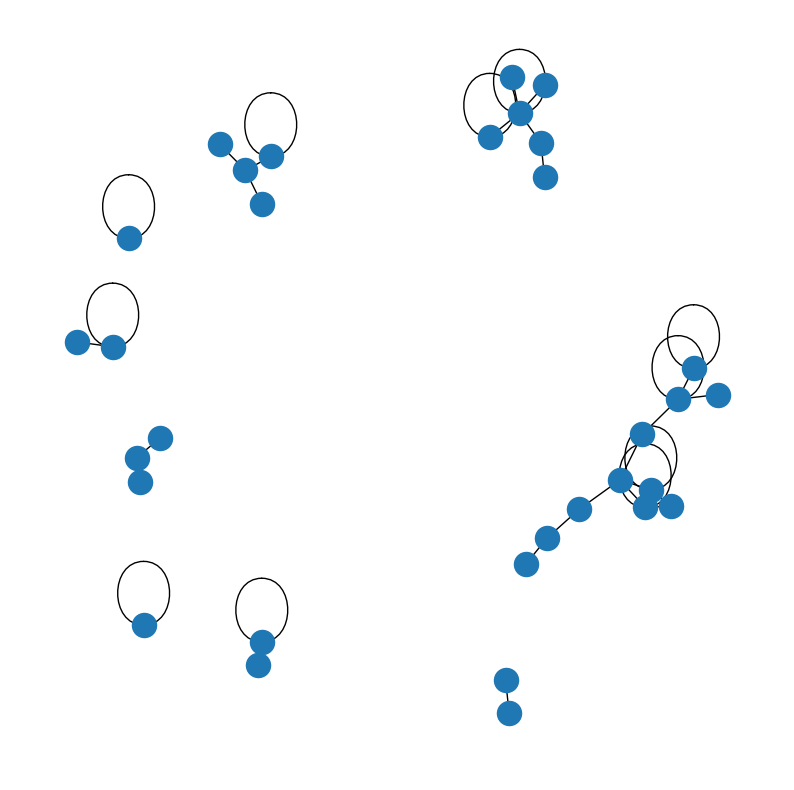

In [ ]:
graph = get_contact_graph(contacts_df)

fig, ax = plt.subplots(figsize=(10, 10))

pos = nx.spring_layout(graph, k=0.2)
nx.draw_networkx_nodes(graph, pos=pos)
nx.draw_networkx_edges(graph, pos=pos, edge_color='black')

for _, spine in ax.spines.items():
    spine.set_visible(False)

plt.show()





In [13]:
# if not os.path.exists('analysis-1-ppi_data.json'):
    
#     outputs = [AlphaFoldOutput(path) for path in output_dirs if os.path.exists(path)]

#     data = list()
#     for output in outputs:
#         contact_probs_df = output.get_contact_probs(models=[output.best_model])
#         paes_df =  output.get_paes(models=[output.best_model])
#         chain_ids = ['A', 'B']

#         idxs, idxs_shifted = get_interface_idxs(contact_probs_df, chain_ids=chain_ids, shift=True)
#         idxs = [idxs[chain_ids[0]], idxs[chain_ids[1]]]

#         data_ = {'name':output.name}
#         data_['iptm'] = np.mean(list(output.get_iptms().values()))
#         data_['idxs'] = idxs
#         data_['idxs_shifted'] = [idxs_shifted[chain_ids[0]], idxs_shifted[chain_ids[1]]]
#         data_['num_contacts'] = len(idxs[0])
#         data_['pae'] = [paes_df.iloc[i, j] for i, j in zip(*idxs)]
#         data_['contact_probs'] = [contact_probs_df.iloc[i, j] for i, j in zip(*idxs)]
#         data.append(data_)

#     with open('analysis-1-ppi_data.json', 'wb') as f:
#         f.write(orjson.dumps(data, default=default))

# else:
#     with open('analysis-1-ppi_data.json', 'r') as f:
#         data = json.load(f)

# data = [data_ for data_ in data if (data_['num_contacts'] > 0)]
# print(f'Loaded data for {len(data)} AlphaFold co-folds with predicted contacts.')


In [14]:
# Jack said that looking at the ipTM is not super informative; there could be a valid protein-protein interaction, but low ipTM due to disordered or low-
# confidence regions. Instead, it would be worth looking at the PAE for residues on different monomers. Any error < 10 A could be worth considering as a potential contact. 

# What would be a good potential statistic for evaluating the likelihood of a protein-protein contact? Want to evaluate both (1) predicted distance and (2) PAE. 
# There is also an output called contact_probs, which is based on a seperate output head in the model (i.e. not the pLDDT or PAE head). This is discussed in the 
# supplement of Jumper et. al. 2021. 

# TODO: Take some notes on this, I don't know if I completely understand. 
# Why isn't PAE symmetric? Asymmetry can arise due to differences in the stability of the selected reference frame. 
# The PAE asks "Asuming this residue is correctly located, how wrong is the other one likely to be?"

In [15]:
ppis = list()
for path in output_dirs:
    cluster_ids = sorted(re.findall(r'cluster_\d+', path))
    assert len(cluster_ids) == 2, f'Only expected 2 gene clusters per file, but got {len(cluster_ids)}.'
    ppis.append('-'.join(cluster_ids))

ppis, counts = np.unique(ppis, return_counts=True)
for ppi, count in zip(ppis, counts):
    print(ppi, count)

# Would be useful to look at the confidence of the residue positions at the interface, and also whether or not the cluster_1-cluster_3 interactions affect the multimerization. 

NameError: name 'output_dirs' is not defined

In [ ]:
# names = list()
# ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
# ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'

# for genome_id, df in genes_df[genes_df.cluster_id.isin([1, 3])].groupby('genome_id'):

#     for pair in itertools.combinations(df.reset_index(names='gene_id').to_dict(orient='records'), 2):
#         name = pair[0]['alphafold_id'].replace('1mer', '6mer') + '-' + pair[1]['alphafold_id'].replace('1mer', '6mer') + '-mg_atp'
#         names.append(name)

#         gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
#         seqs = [pair[0]['seq'], pair[1]['seq']]

#         msas = dict()
#         msas['unpaired'] = get_msas_unpaired(gene_ids)

#         file = AlphaFoldInputFile(name, dialect='alphafoldserver', num_seeds=1, version=1)

#         for gene_id, seq in zip(gene_ids, seqs):
#             file.add_seq(seq, paired_msa=msas['paired'][gene_id], unpaired_msa=msas['unpaired'][gene_id], n=6)
#         file.add_atp(n=6)
#         file.add_mg(n=6)

#         file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{name}.json'))



In [ ]:
# It seems as though the cluster_1-cluster_3 contact is only predicted highly with the cluster_3 monomer. But is this a failing of AlphaFold?
# Do the contacting residues differ between the monomer predictions and the multimer predictions (i.e. does cluster_3 multimerizing block 
# the preferred interface for cluster_1 and cluster_3)?

In [ ]:
# def get_msas_paired(gene_ids:list, dir_path:str=MMSEQS_DIR):
#     '''Construct paired MSAs using the specified gene IDs as queries. This is done by:
#         (1) Loading the unpaired MSA for each query gene ID. 
#         (2) Filtering each unpaired MSA to include only genes from genomes which are represented in both, i.e. contain identified homologs of each query sequence. 
#         (3) Sorting the MSAs alphabetically by gene ID (ensuring the query is still the first entry) so that rows correspond.
        
#     :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
#     :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
#         sequence. 
#     '''
#     assert len(set([get_genome_id(gene_id) for gene_id in gene_ids])) == 1, 'get_msas_paired: Expected all genes to be from the same genome.'

#     paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
#     msas = {gene_id:FASTAFile.from_file(path).to_df().reset_index(names='gene_id') for gene_id, path in paths.items()}
#     msas = {gene_id:df.assign(genome_id=df.gene_id.apply(get_genome_id)) for gene_id, df in msas.items()}

#     genome_ids = None
#     for _, df in msas.items(): # Get all genome IDs which have a representative for all chains. 
#         genome_ids = df.genome_id.unique() if (genome_ids is None) else np.intersect1d(genome_ids, df.genome_id.unique())
    
#     if len(genome_ids) < 2:
#         # If there are two few genome IDs, the paired MSA will just contain the genes from the query genome (but do not want it to throw an error). 
#         print('get_msas_paired: Too few paired sequences for a proper paired MSA.')

#     sort = lambda df : pd.concat([df.iloc[:1], df.iloc[1:].sort_values('gene_id')]) # Sort a DataFrame by genome ID, while holding the query row fixed.
#     msas = {gene_id:sort(df[df.genome_id.isin(genome_ids)].copy()) for gene_id, df in msas.items()}
    
#     return {gene_id:str(FASTAFile.from_df(df.set_index('gene_id'))) for gene_id, df in msas.items()}
